In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\ABINAYA\Downloads\predictive_maintenance.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
df['rolling_air_temp_win3']=df['Air temperature [K]'].rolling(window=3).mean()

In [10]:
df['rolling_air_temp_win3'].describe()

count    9998.000000
mean      300.005218
std         1.999868
min       295.300000
25%       298.333333
50%       300.066667
75%       301.500000
max       304.433333
Name: rolling_air_temp_win3, dtype: float64

Since the air temperature is very stable from this 

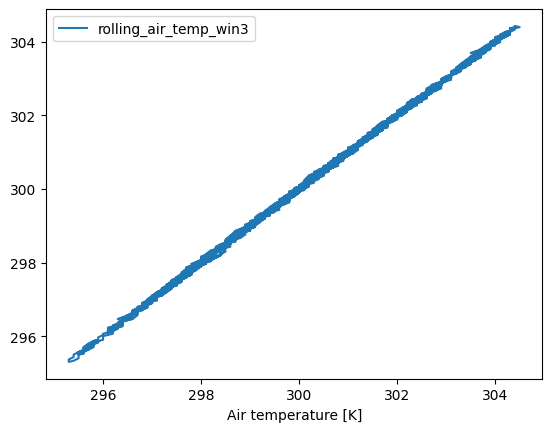

In [16]:
line_plot=df.plot.line(x='Air temperature [K]',y='rolling_air_temp_win3')   

In [14]:
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16,0.003333,0.003
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14,0.003333,0.003
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14,0.000000,0.003
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16,0.013333,0.008
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22,0.040000,0.032


In [6]:
df['rolling_air_temp_win5']=df['Air temperature [K]'].rolling(window=5).mean()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22


#Observation of Rolling mean

The rolling mean was calculated using window sizes of 3 and 5 of the Air temperature feature. The rolling mean values were found to be very close to the originl temperature values, indicating that there are no sudden fluctuations in air temperature. Most values remain within a narrow range around the overall mean temperature, suggesting that the environmental conditions are relativey stable throughout the dataset

In [7]:
df['rolling_air_temp_variance_win3']=df['Air temperature [K]'].rolling(window=3).var()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16,0.003333
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14,0.003333
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14,0.000000
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16,0.013333
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22,0.040000


<Axes: >

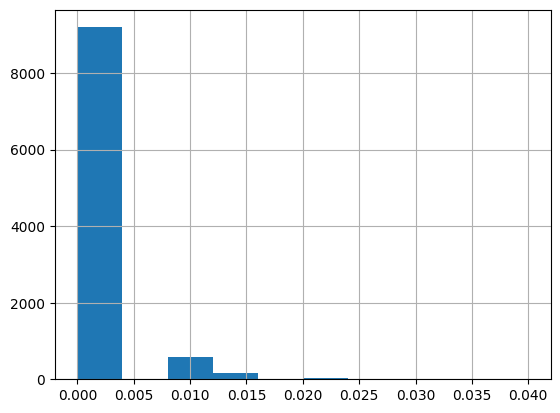

In [15]:
df['rolling_air_temp_variance_win3'].hist()

In [8]:
df['rolling_air_temp_variance_win5']=df['Air temperature [K]'].rolling(window=5).var()
df.head(15)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,rolling_air_temp_win3,rolling_air_temp_win5,rolling_air_temp_variance_win3,rolling_air_temp_variance_win5
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,NaN,NaN,NaN,NaN
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,NaN,NaN,NaN,NaN
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,298.133333,NaN,0.003333,NaN
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,298.166667,NaN,0.003333,NaN
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,298.166667,298.16,0.003333,0.003
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure,298.166667,298.16,0.003333,0.003
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure,298.133333,298.14,0.003333,0.003
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure,298.100000,298.14,0.000000,0.003
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure,298.166667,298.16,0.013333,0.008
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure,298.300000,298.22,0.040000,0.032


#Observation of rolling variance analysis

The rolling variance was calculated using the window sized of 3 and 5 to measure short term temperature fluctuations. The histogram of the rolling variance shows that the majority of the observations falls within the range of 0.000 to 0.004. This indicates that the variation in air temperature is very loew of most obervations. 
Only a small number of observation exhibit higher variance values , which suggests occasional fluctuations in temperature. However, these occurrences are infrequent compared to overall dataset.